## 1. Setup and Imports {#setup}

Let's start by importing all necessary modules and setting up the environment.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import sys
import os
warnings.filterwarnings('ignore')

import sys
import os
sys.path.insert(0, '/home/HX46_FR5/repo_perso/AbXtract')


from AbXtract import *
from AbXtract import AntibodyDescriptorCalculator, Config, load_config
from AbXtract.sequence import (
    SequenceLiabilityAnalyzer,
    BashourDescriptorCalculator,
    PeptideDescriptorCalculator,
    AntibodyNumbering
)
from AbXtract.structure import (
    SASACalculator,
    ChargeAnalyzer,
    DSSPAnalyzer,
    PropkaAnalyzer,
    ArpeggioAnalyzer
)
from AbXtract.utils import (
    read_fasta,
    write_fasta,
    parse_sequence,
    validate_sequence,
    analysis_descriptors
)


# 2. Function to combine descriptors and class them

In [2]:
def desc_Ab(HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE):
    
    if HEAVY_SEQUENCE:
        heavy_valid, heavy_msg = validate_sequence(HEAVY_SEQUENCE)
        heavy_numbered = numbering.number_sequence(HEAVY_SEQUENCE, 'H')  # Use VH portion only
        annotated_H, cdrs_H = numbering.get_cdr_sequences(heavy_numbered, 'H')
        heavy_profiles = numbering.get_peptide_profiles(HEAVY_SEQUENCE)
    
    if LIGHT_SEQUENCE:
        light_valid, light_msg = validate_sequence(LIGHT_SEQUENCE)
        light_numbered = numbering.number_sequence(LIGHT_SEQUENCE, 'L')  # Use VH portion only    
        annotated_L, cdrs_L = numbering.get_cdr_sequences(light_numbered, 'L')
        light_profiles = numbering.get_peptide_profiles(LIGHT_SEQUENCE)

    peptide_results = peptide_calc.calculate_all(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE
    )

    sequence_results, liabilities = calc.calculate_sequence_descriptors(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE,
    sequence_id="TestAb_Sequence"
    )

    structure_results_seq, structure_results_comp, df_residues, df_AA, df_Ab = calc.calculate_structure_descriptors(
    heavy_sequence=HEAVY_SEQUENCE,
    light_sequence=LIGHT_SEQUENCE,
    pdb_file=PDB_FILE,
    structure_id="TestAb_Structure"
    )
    
        
    # Ensure residue_sasa_sum column exists
    structures_results_seq = analysis_descriptors.add_residue_sasa_sum_column(structure_results_seq)

    # Get data
    liabilities_list = liabilities['liabilities'].iloc[0]
    structures_data = structures_results_seq.iloc[0]

    if HEAVY_SEQUENCE:
        df_heavy_final = analysis_descriptors.create_complete_antibody_dataframe( 0, df_residues, df_Ab, 
            HEAVY_SEQUENCE, annotated_H, heavy_profiles, 
            structures_data, liabilities_list, 'Heavy', 'imgt'
                                                           
        )
    else:
        df_light_final = None
        
    if LIGHT_SEQUENCE:
        df_light_final = analysis_descriptors.create_complete_antibody_dataframe(len(HEAVY_SEQUENCE), df_residues, df_Ab, 
            LIGHT_SEQUENCE, annotated_L, light_profiles,
            structures_data, liabilities_list, 'Light', 'imgt'
                                                            
        )
    else:
        df_light_final = None
        
    df_final = analysis_descriptors.combine_all_results(
        df_AA,
        structure_results_comp,
        sequence_results,
        peptide_results,
        heavy_valid=heavy_valid,
        light_valid=light_valid,
        cdrs_H=cdrs_H,
        cdrs_L=cdrs_L
    )

    return(df_heavy_final, df_light_final, df_final)

# Load config

In [3]:
# default configuration
custom_config = Config()

'''
# Test custom configuration
custom_config = Config.from_dict({
    'pH': 7.4,
    'numbering_scheme': 'kabat',
    'verbose': True,
    'calculate_dssp': tool_status.get('dssp', False),
    'calculate_propka': tool_status.get('propka', False),
    'calculate_arpeggio': tool_status.get('arpeggio', False)
})
'''


# Check external tool availability
tool_status = custom_config.check_external_tools()
print("🛠️ External Tool Status:")
for tool, available in tool_status.items():
    status = "✅" if available else "❌"
    print(f"  {tool}: {status}")


reduce not found at reduce


🛠️ External Tool Status:
  dssp: ✅
  propka: ✅
  arpeggio: ✅
  reduce: ❌
  muscle: ✅


# Load classes

In [4]:
numbering = AntibodyNumbering(scheme='imgt')
peptide_calc = PeptideDescriptorCalculator()
calc = AntibodyDescriptorCalculator(config=custom_config)

reduce not found at reduce
Missing external tools: reduce
Some analyses may not be available


--- 0.5164973735809326 seconds --- INITIALIZATION


# Define path 

In [5]:
abxtract_path = "/home/HX46_FR5/repo_perso/AbXtract"
sys.path.insert(0, abxtract_path)

# Set up test data paths
BASE_DIR = Path.cwd() 
DATA_DIR = BASE_DIR / "data" / "test"
DATA_DIR.mkdir(parents=True, exist_ok=True)


# Define test file paths
RESULTS_DIR = DATA_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)


# Input sequence and pdb

In [6]:
# Test antibody sequences (based on therapeutic antibodies)
HEAVY_SEQUENCE_list = (
    "QVQLVQSGAEVKKMQPERTSACKVSGGTFGRYGIHWVRQAPGKGLEASVGISPSGGTTIYAQKFQGRVTMTEDTSLKPRYMELSSLKSEDTAVYYCAREKDGYPGKGFDIWGQGTMVTVSS",
    "QVQLVQSGAEVKKMLKPRTSACKVSGGTFGRYGIHWVRQAPGKGLEASVGISPSGGTTIYAQKFQGIHWVRQTSLKPRYMELSSLKSEDTAVYYCAREKDGYPGKGFDIWGQGTMVTVSS",
    "QVQLVQSGAEVKKMLKPRTSACKVSQPETFGRYGIHWVRQAPGKGLEASVGISPSGGTTIHWVRQFQGRVTMTEDTSLKPRYMELSSLKSEDTAVYYCAREKDGYPGKGFDIWGQGTMVTVSS",
    "QVQLVQSGAEVKKMLKPRQPEACKVSGIHWVRQYGIHWVRQAPGKGLEASVGISPSGGTTIYAQKFQGRVTMTEDTSLKPRYMELSSLKSEDTAVYYCAREKDGYPGKGFDIWGQGTMVTVSS"
)
# Light chain: Includes realistic VL domain + human kappa constant region  
LIGHT_SEQUENCE_list = (
    "DIQMTQSPSSVSASVGDRVTPGKGASHSIQPELAWYQQKPGKAPKLLIYYAIHWVRQPRVPSRFSGASVGTDFTLTISSLQPEDFANYYCQQADNLPFTFGGGTKVEIK",
    "DIQMTQSPSSVSASVGDRVTIHQPEQASHSIGTYLAWYQQKPGKAPKLLIYYASRLKPRVPSRFSGASVGTDFTLTISSLQPEDFANYYCQQADNLPFTFGGGTKVEIK",
    "DIQMTQSPSSVSASVGIHWVRQTPGKGASHSIGTYLAWYQQKPGKAPKLLIYYASRLKPRVPSRFSGASVGTDFTLTISSLQPEDFANYYCQQADNLPFTFGGGTKVEIK",
    "DIQMTQSPSSVSASVGDRVTPGKGASIHWVRQTYLAWYQQQPEPGKAPKLLIYYASRLKPRVPSRFSGASVGTDFTLTISSLQPEDFANYYCQQADNLPFTFGGGTKVEIK"
)
PDB_FILE_list = [
    DATA_DIR / "test1.pdb",  # User will provide this
    DATA_DIR / "test2.pdb",
    DATA_DIR / "test3.pdb",
    DATA_DIR / "test4.pdb"
]

# Proper descriptors

In [7]:
from AbXtract import AntibodyDescriptorCalculator

# Initialize calculator
calc = AntibodyDescriptorCalculator()

reduce not found at reduce
Missing external tools: reduce
Some analyses may not be available


--- 0.491321325302124 seconds --- INITIALIZATION


# Sequence validity for numbering

In [8]:
df_fin = []
for HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE in zip(HEAVY_SEQUENCE_list, LIGHT_SEQUENCE_list, PDB_FILE_list):
    df_heavy_final, df_light_final, df_final = desc_Ab(HEAVY_SEQUENCE, LIGHT_SEQUENCE, PDB_FILE)
    df_fin.append(df_final)

--- 0.10748648643493652 seconds --- self.Calculate numbering
--- 0.0893857479095459 seconds --- self.config.calculate_liabilities
--- 0.036676645278930664 seconds --- self.config.calculate_bashour
--- 47.829911947250366 seconds --- self.config.calculate_peptide
--- 7.479081630706787 seconds --- self.config.calculate_protpy


@> 3499 atoms and 1 coordinate set(s) were parsed in 0.03s.


--- 0.25543212890625 seconds --- Calculate SASA and SAP
--- 0.058252573013305664 seconds --- Calculate charge properties
--- 0.04475259780883789 seconds --- Calculate disulfide bonds
--- 0.04671669006347656 seconds --- Calculate charge dispersion


DSSP analysis failed: DSSP failed to produce an output


--- 0.08762717247009277 seconds --- Extended SASA analysis
--- 0.06290650367736816 seconds --- Run DSSP
--- 0.8703348636627197 seconds --- Run Extended PROPKA
--- 32.39559078216553 seconds --- Run computeProper
--- 0.29137444496154785 seconds --- Run Arpeggio
--- 3.814697265625e-06 seconds --- Calculate developability index
--- 0.11726093292236328 seconds --- self.Calculate numbering
--- 0.09052824974060059 seconds --- self.config.calculate_liabilities
--- 0.03600740432739258 seconds --- self.config.calculate_bashour
--- 48.35766124725342 seconds --- self.config.calculate_peptide
--- 7.318445444107056 seconds --- self.config.calculate_protpy


...

--- 0.0682668685913086 seconds --- Run DSSP
--- 0.7611312866210938 seconds --- Run Extended PROPKA
--- 31.723074913024902 seconds --- Run computeProper
--- 0.30473875999450684 seconds --- Run Arpeggio
--- 3.5762786865234375e-06 seconds --- Calculate developability index
--- 0.12269711494445801 seconds --- self.Calculate numbering
--- 0.0962827205657959 seconds --- self.config.calculate_liabilities
--- 0.03783702850341797 seconds --- self.config.calculate_bashour
--- 48.54001498222351 seconds --- self.config.calculate_peptide
--- 7.685326814651489 seconds --- self.config.calculate_protpy


@> 3616 atoms and 1 coordinate set(s) were parsed in 0.04s.


--- 0.2680084705352783 seconds --- Calculate SASA and SAP
--- 0.2209031581878662 seconds --- Calculate charge properties
--- 0.04592418670654297 seconds --- Calculate disulfide bonds
--- 0.04715728759765625 seconds --- Calculate charge dispersion
--- 0.09313154220581055 seconds --- Extended SASA analysis


DSSP analysis failed: DSSP failed to produce an output


--- 0.07491874694824219 seconds --- Run DSSP
--- 0.7704358100891113 seconds --- Run Extended PROPKA
--- 31.22179388999939 seconds --- Run computeProper
--- 0.2947094440460205 seconds --- Run Arpeggio
--- 4.291534423828125e-06 seconds --- Calculate developability index


# Object descriptors

In [9]:
df_test = pd.concat(df_fin, axis = 0)
df_mod = analysis_descriptors.prepare_object_descriptors(df_test)
df_mod

,heavy_sequence,light_sequence,scheme,Light_valid,Heavy_valid,Light_cdrl1,Light_cdrl2,Light_cdrl3,Heavy_cdrh1,Heavy_cdrh2,...,surface_vs_buried_ip_diff,theoretical_pi_pH7.4,titratable_residues,total_MW,total_cys,total_exposed,total_possible,total_sasa,total_sasa_sidechain,unusual_pka_count
0,QVQLVQSGAEVKKMQPERTSACKVSGGTFGRYGIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTPGKGASHSIQPELAWYQQKPGKAPKL...,imgt,True,True,HSIQPE,YAIHW,QQADNLPFT,GGTFGRYG,ISPSGGTT,...,0.387284,8.787494,63.0,29177.59,3,111,12,11035.502315,8445.193183,8.0
0,QVQLVQSGAEVKKMLKPRTSACKVSGGTFGRYGIHWVRQAPGKGLE...,DIQMTQSPSSVSASVGDRVTIHQPEQASHSIGTYLAWYQQKPGKAP...,imgt,True,True,HSIGTY,YAS,QQADNLPFT,GGTFGRYG,ISPSGGTT,...,0.426206,9.266043,61.0,29155.69,3,106,12,11342.028326,8639.523923,10.0
0,QVQLVQSGAEVKKMLKPRTSACKVSQPETFGRYGIHWVRQAPGKGL...,DIQMTQSPSSVSASVGIHWVRQTPGKGASHSIGTYLAWYQQKPGKA...,imgt,True,True,HSIGTY,YAS,QQADNLPFT,QPETFGRYG,ISPSGGTTI,...,0.459790,9.276881,63.0,29753.38,3,109,12,12088.630093,9212.258300,12.0
0,QVQLVQSGAEVKKMLKPRQPEACKVSGIHWVRQYGIHWVRQAPGKG...,DIQMTQSPSSVSASVGDRVTPGKGASIHWVRQTYLAWYQQQPEPGK...,imgt,True,True,IHWVRQTY,YAS,QQADNLPFT,GIHWVRQYG,ISPSGGTT,...,0.415595,9.068681,62.0,29984.63,3,113,12,12069.003055,9191.318874,10.0


# Evolution pH

In [10]:
patterns = ["Light_Charges_pH_","Heavy_Charge_pH_","Free_Energy_kcal_mol_",
            "Protein_Charge_Unfolded_","Protein_Charge_Folded_pH_",
            "pI_Folded_pH_","pI_Unfolded_pH_"]
col_ph = sorted([col for col in df_test.columns 
                 if any(pattern in col for pattern in patterns)])
object_0_df = analysis_descriptors.reshape_dataframe_by_object(df_test[col_ph])[0]

In [11]:
object_0_df

,pH_0.00,pH_0.10,pH_0.20,pH_0.30,pH_0.40,pH_0.50,pH_0.60,pH_0.70,pH_0.80,pH_0.90,...,pH_13.10,pH_13.20,pH_13.30,pH_13.40,pH_13.50,pH_13.60,pH_13.70,pH_13.80,pH_13.90,pH_14.00
Free_Energy_kcal_mol,50.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.880000
Heavy_Charge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-19.819970
Light_Charges,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-15.850641
Protein_Charge_Folded,31.96,31.95,31.94,31.93,31.91,31.89,31.86,31.83,31.79,31.75,...,-28.21,-28.61,-29.00,-29.36,-29.71,-30.04,-30.36,-30.66,-30.94,-31.210000
Protein_Charge_Unfolded,32.00,32.00,32.00,31.99,31.99,31.99,31.99,31.98,31.98,31.98,...,-31.74,-32.13,-32.46,-32.75,-32.98,-33.17,-33.33,-33.47,-33.57,-33.660000
pI_Folded,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.41,...,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.41,9.410000
pI_Unfolded,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.60,...,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.60,9.600000


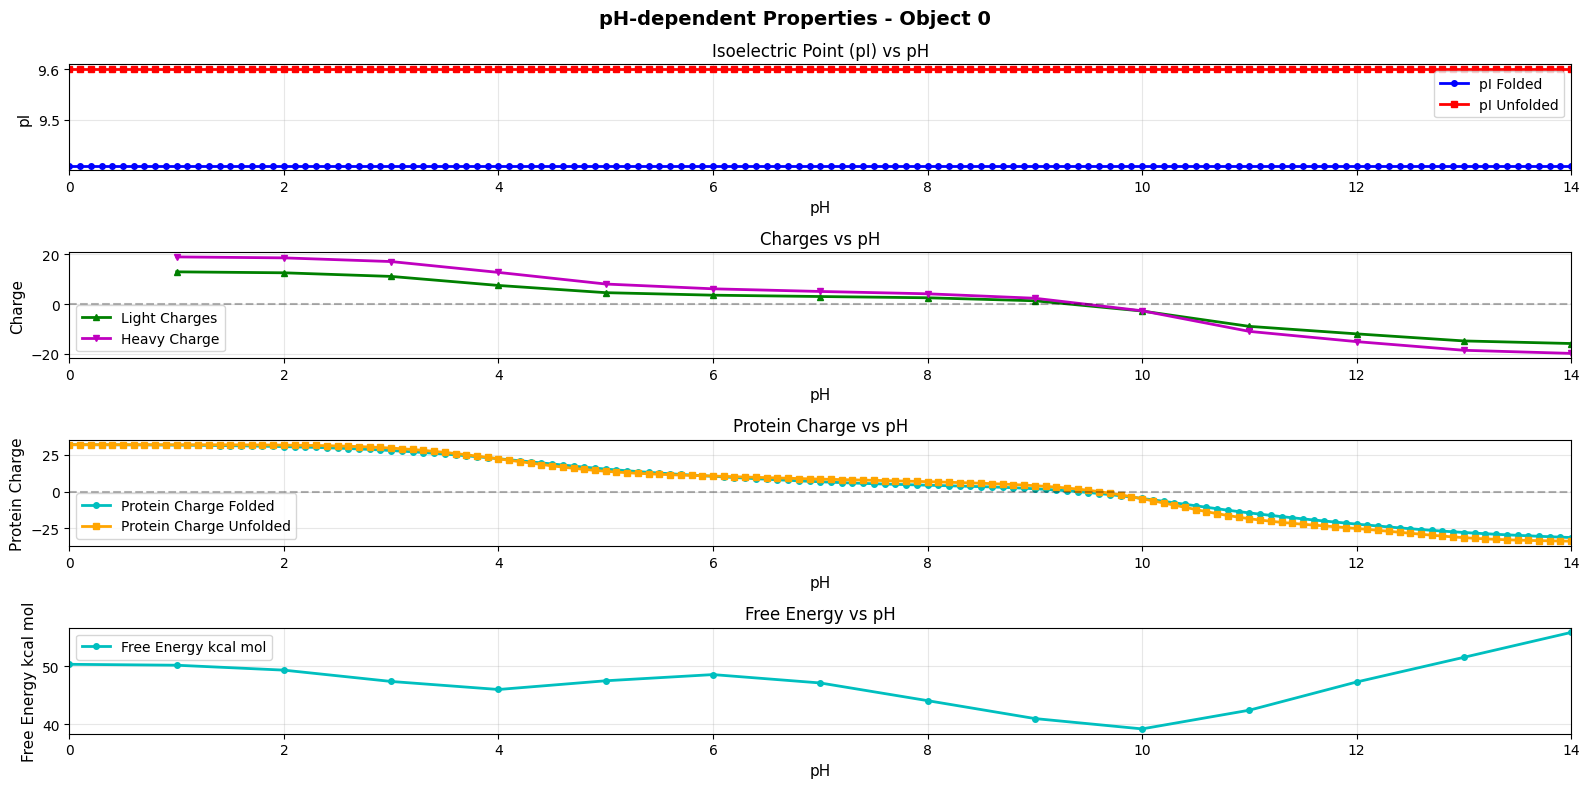

In [12]:
fig = analysis_descriptors.plot_ph_profiles(object_0_df, object_id=0)
plt.show()


# Residue mapping

In [13]:
df_heavy_final.style

,position_seq,position_num,amino_acid,region,disulfide_bond,sap,high_sap,sidechain_sasa,buried,pka,pka_shift,residue_sasa_sum,SASA,RASA,EXP_HSE_B_U,EXP_HSE_B_D,EXP_HSE_A_U,EXP_HSE_A_D,hydrophobicity,mean_IP,max_IP,min_IP,mean_dpx,CA_x,CA_y,CA_z,residue_name_U,charge,charge_sign,hydrophobicity_hw,hydrophobicity_eisenberg,hydrophobicity_rose,hydrophobicity_janin,hydrophobicity_engelman,Buried ratio_propka,Disolvation regular Cst_propka,Disolvation regular Nb_propka,Effects RE Cst_propka,Effects RE Nb_propka,Unpaired_Cys,N-linked_glycosylation,Met_oxidation,Trp_oxidation,Asn_deamidation,Asp_isomerisation,Lysine_Glycation,N-terminal_glutamate,Integrin_binding,CD11c/CD18_binding,Fragmentation,Polyreactivity
0,1,1.000000,Q,fwh1,False,0.027590,False,15.828671,False,None,None,15.828671,51.010000,28.659000,13.000000,10.000000,nan,nan,-3.500000,-0.167000,-0.305000,0.053000,2.251000,-14.443000,11.823000,-3.260000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2.000000,V,fwh1,False,0.717353,True,101.733674,False,None,None,101.733674,115.400000,77.273000,0.000000,21.000000,0.000000,21.000000,4.200000,0.075000,-0.170000,0.521000,1.593000,-14.167000,10.763000,0.726000,VAL,0.000000,0.000000,-1.500000,1.080000,0.860000,0.600000,-2.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
2,3,3.000000,Q,fwh1,False,0.004481,False,2.570732,True,None,None,2.570732,1.700000,0.955000,18.000000,6.000000,15.000000,9.000000,-3.500000,-0.285000,-0.432000,-0.094000,2.716000,-14.813000,8.084000,2.292000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
3,4,4.000000,L,fwh1,False,0.815140,True,118.424380,False,None,None,118.424380,120.630000,67.819000,3.000000,23.000000,3.000000,23.000000,3.800000,0.034000,-0.281000,0.499000,1.790000,-13.635000,6.132000,5.054000,LEU,0.000000,0.000000,-1.800000,1.060000,0.850000,0.500000,-2.800000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
4,5,5.000000,V,fwh1,False,0.003269,False,0.463588,True,None,None,0.463588,2.140000,1.433000,22.000000,12.000000,26.000000,8.000000,4.200000,-0.413000,-0.489000,-0.234000,3.660000,-13.210000,2.426000,5.002000,VAL,0.000000,0.000000,-1.500000,1.080000,0.860000,0.600000,-2.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
5,6,6.000000,Q,fwh1,False,0.204664,False,117.417080,False,None,None,117.417080,127.090000,71.403000,11.000000,17.000000,7.000000,21.000000,-3.500000,0.044000,-0.326000,1.148000,1.663000,-14.926000,0.887000,8.037000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
6,7,7.000000,S,fwh1,False,0.116423,False,23.673749,False,None,None,23.673749,61.960000,53.738000,14.000000,14.000000,15.000000,13.000000,-0.800000,-0.020000,-0.219000,0.233000,1.712000,-12.612000,-1.525000,10.043000,SER,0.000000,0.000000,0.300000,-0.180000,0.660000,-0.100000,-0.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
7,8,8.000000,G,fwh1,False,0.000000,False,0.000000,False,None,None,0.000000,38.450000,47.740000,13.000000,11.000000,11.000000,13.000000,-0.400000,-0.122000,-0.269000,0.027000,1.588000,-13.453000,-5.281000,11.140000,GLY,0.000000,0.000000,0.000000,0.480000,0.720000,0.300000,-1.000000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
8,9,9.000000,A,fwh1,False,0.572166,True,62.232328,False,None,None,62.232328,97.160000,90.601000,2.000000,18.000000,0.000000,20.000000,1.800000,0.477000,0.037000,1.127000,1.530000,-12.028000,-6.619000,14.437000,ALA,0.000000,0.000000,-0.500000,0.620000,0.740000,0.300000,-1.600000,0,0.53,210,0.00,0,False,False,F

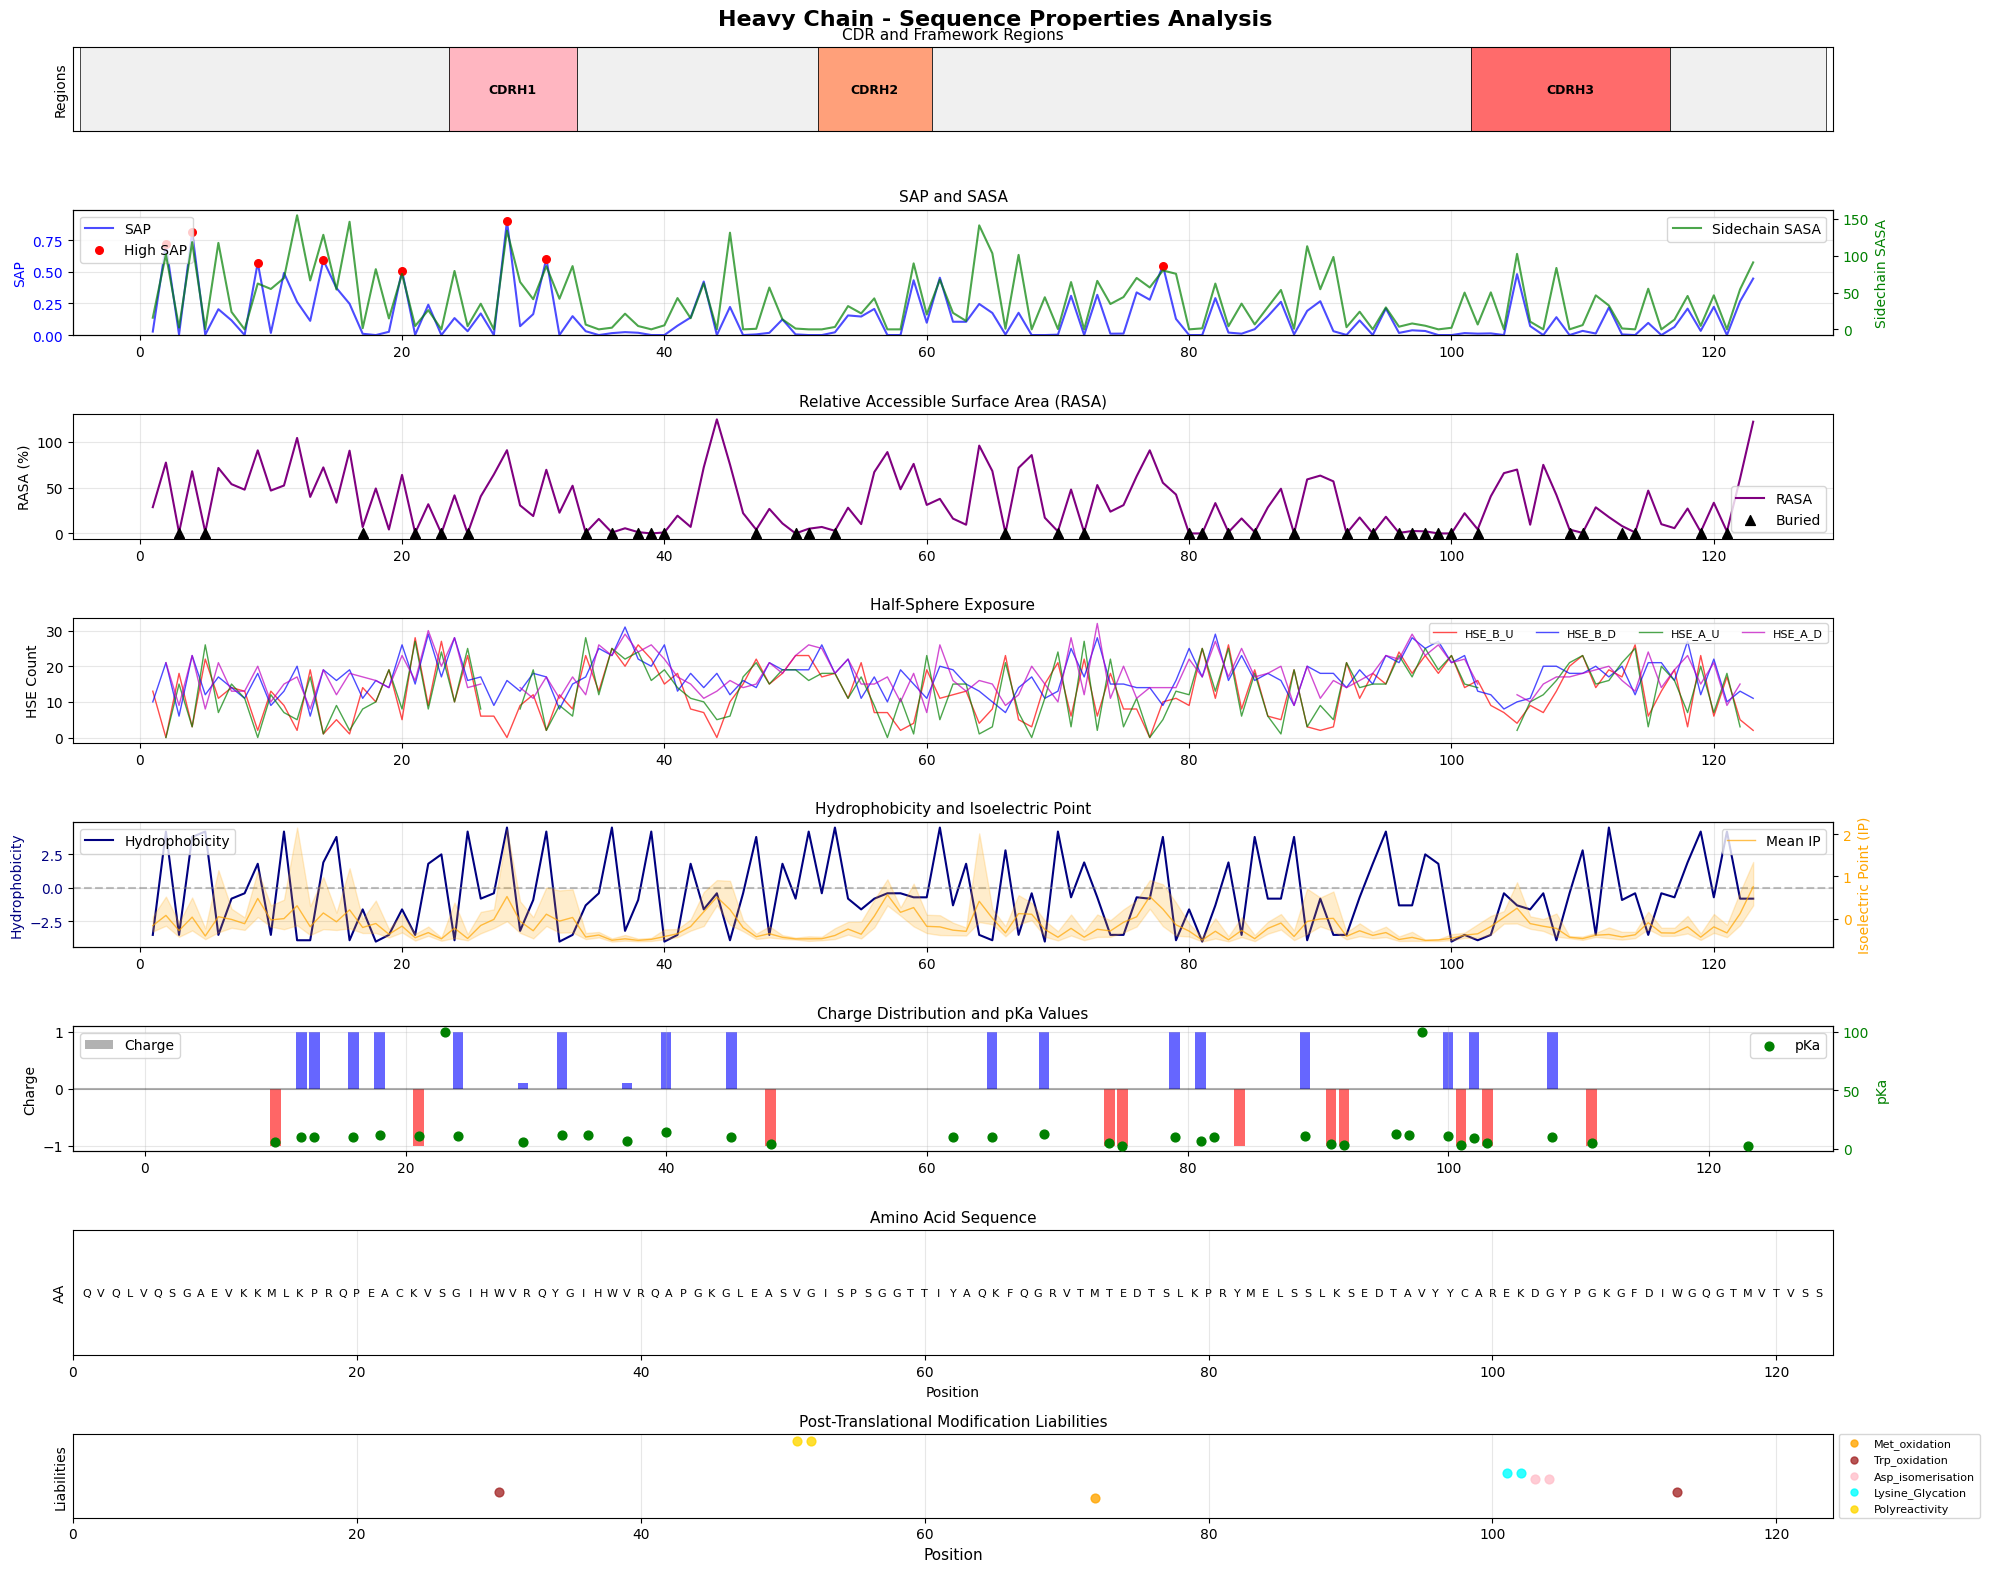

In [14]:
fig = analysis_descriptors.plot_protein_properties(df_heavy_final, chain_type='heavy')
plt.show()


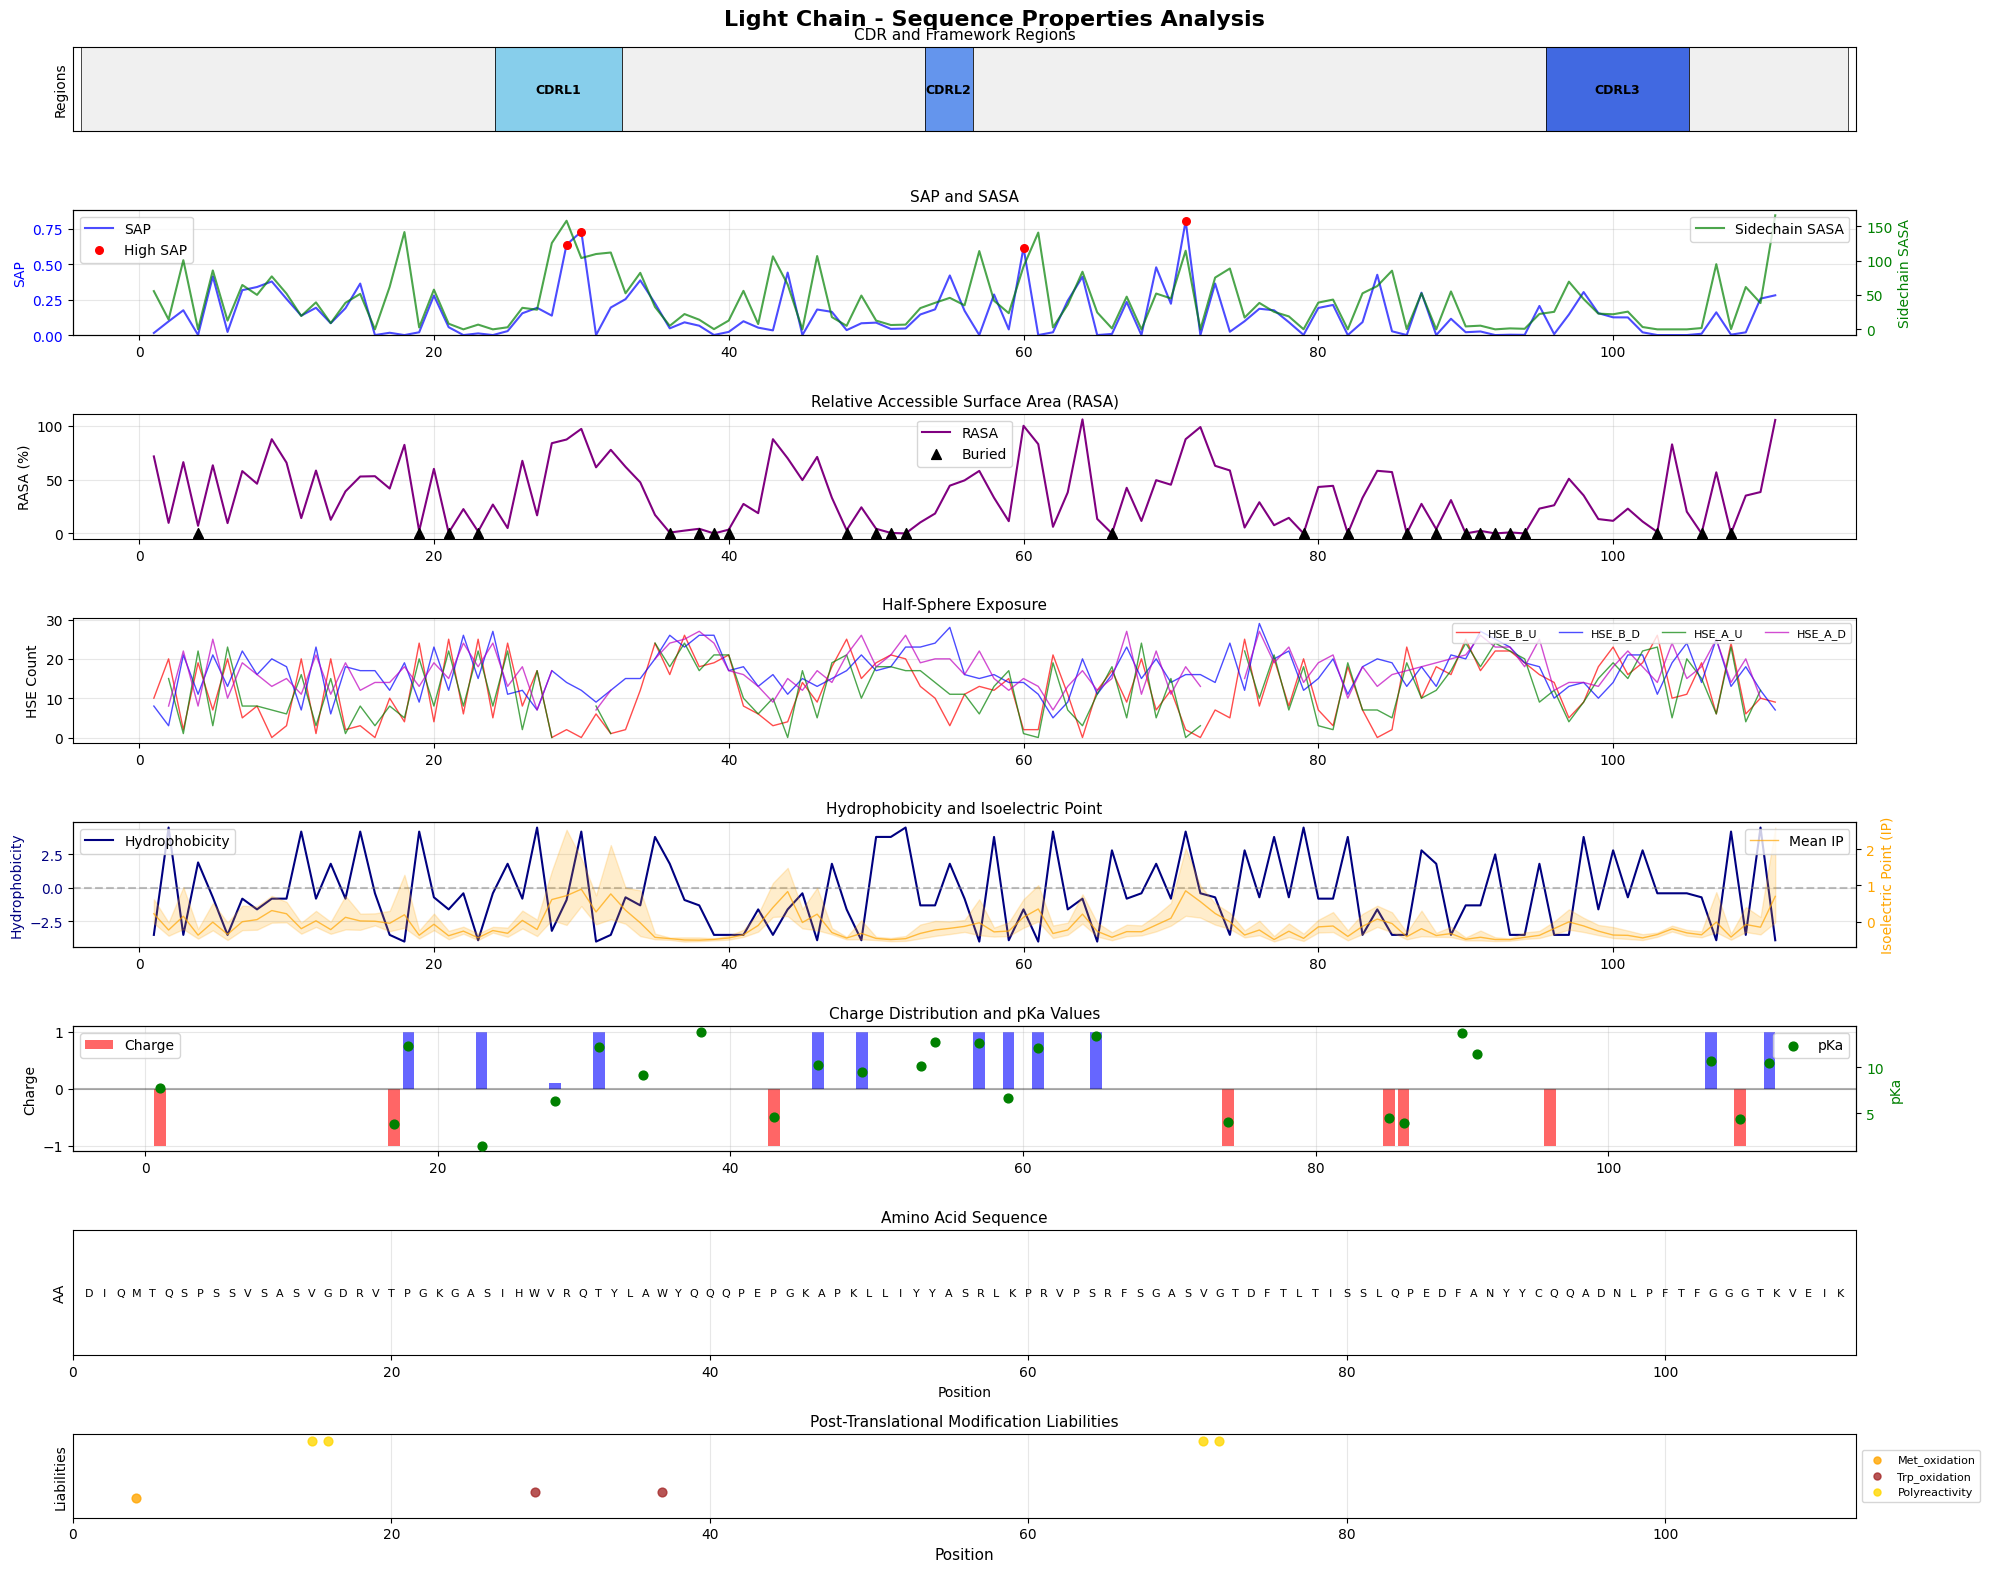

In [15]:
fig_heavy = analysis_descriptors.plot_protein_properties(df_light_final, chain_type='light')
plt.show()


# Propka spe

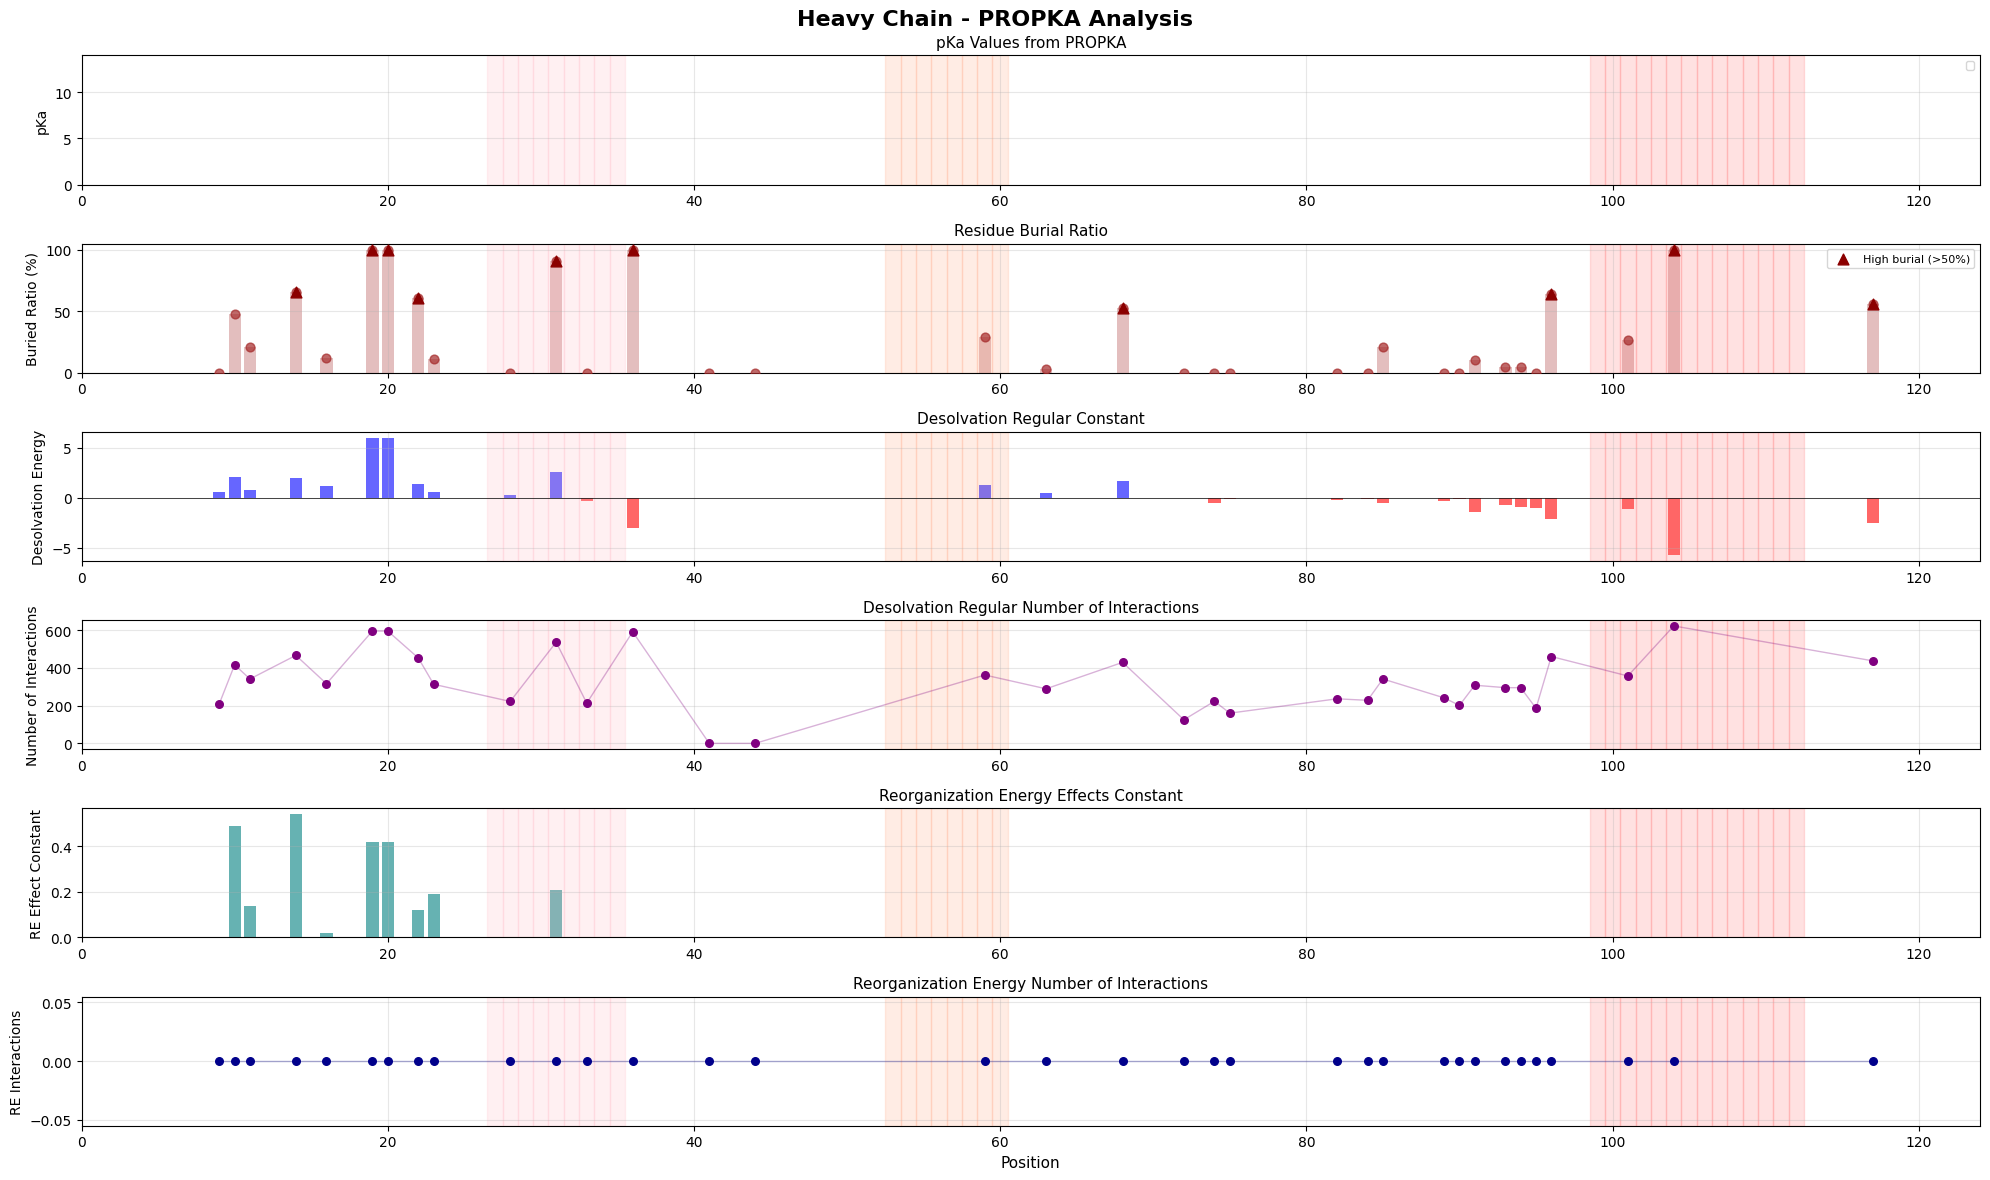

In [16]:
fig_propka_heavy = analysis_descriptors.plot_propka_properties(df_heavy_final, chain_type='heavy')
plt.show()


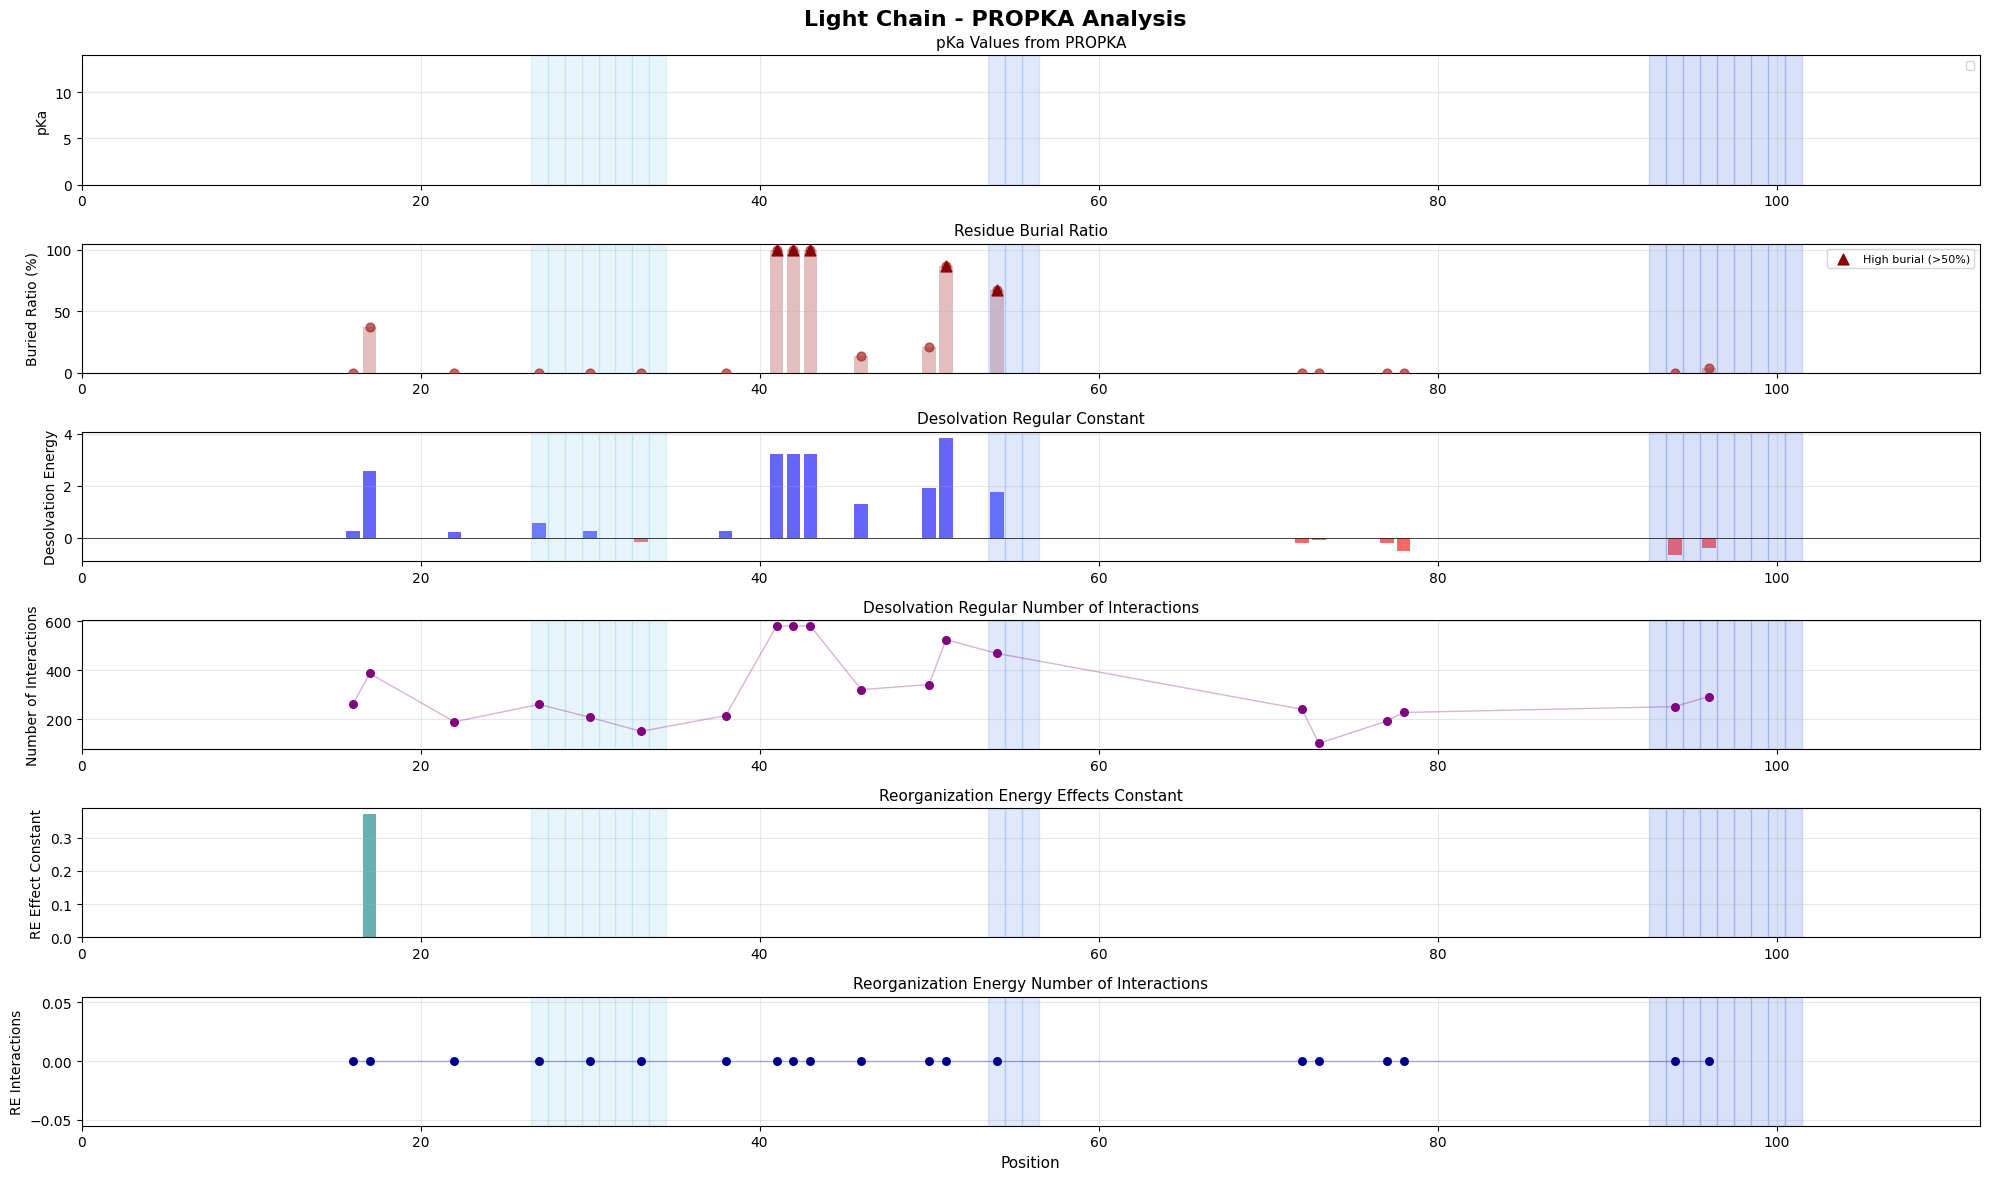

In [17]:
fig_propka_light = analysis_descriptors.plot_propka_properties(df_light_final, chain_type='light')
plt.show()

In [18]:
df_light_final.style

,position_seq,position_num,amino_acid,region,disulfide_bond,sap,high_sap,sidechain_sasa,buried,pka,pka_shift,residue_sasa_sum,SASA,RASA,EXP_HSE_B_U,EXP_HSE_B_D,EXP_HSE_A_U,EXP_HSE_A_D,hydrophobicity,mean_IP,max_IP,min_IP,mean_dpx,CA_x,CA_y,CA_z,residue_name_U,charge,charge_sign,hydrophobicity_hw,hydrophobicity_eisenberg,hydrophobicity_rose,hydrophobicity_janin,hydrophobicity_engelman,Buried ratio_propka,Disolvation regular Cst_propka,Disolvation regular Nb_propka,Effects RE Cst_propka,Effects RE Nb_propka,Unpaired_Cys,N-linked_glycosylation,Met_oxidation,Trp_oxidation,Asn_deamidation,Asp_isomerisation,Lysine_Glycation,N-terminal_glutamate,Integrin_binding,CD11c/CD18_binding,Fragmentation,Polyreactivity
0,1,1.000000,D,fwl1,False,0.014672,False,55.544655,False,7.780000,-0.220000,15.828671,103.000000,71.498000,10.000000,8.000000,nan,nan,-3.500000,0.215000,-0.044000,0.615000,1.478000,5.214000,-10.415000,-12.327000,ASP,-1.000000,-1.000000,3.000000,-0.900000,0.620000,-0.600000,9.200000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
1,2,2.000000,I,fwl1,False,0.096458,False,14.320390,False,None,None,101.733674,16.990000,9.798000,20.000000,3.000000,15.000000,8.000000,4.500000,-0.234000,-0.391000,-0.026000,2.215000,7.343000,-7.178000,-11.850000,ILE,0.000000,0.000000,-1.800000,1.380000,0.880000,0.700000,-3.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
2,3,3.000000,Q,fwl1,False,0.175228,False,100.529458,False,None,None,2.570732,117.830000,66.200000,2.000000,21.000000,1.000000,22.000000,-3.500000,0.147000,-0.208000,0.948000,1.703000,9.793000,-7.377000,-9.228000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
3,4,4.000000,M,fwl1,False,0.000344,False,0.074516,True,None,None,118.424380,13.260000,7.099000,19.000000,11.000000,22.000000,8.000000,1.900000,-0.375000,-0.472000,-0.208000,2.870000,10.698000,-4.160000,-7.508000,MET,0.000000,0.000000,-1.300000,0.640000,0.850000,0.400000,-3.400000,nan,nan,nan,nan,nan,False,False,True,False,False,False,False,False,False,False,False,False
4,5,5.000000,T,fwl1,False,0.414075,False,85.575403,False,None,None,0.463588,86.420000,63.270000,7.000000,21.000000,3.000000,25.000000,-0.700000,-0.016000,-0.242000,0.510000,1.672000,14.131000,-4.018000,-5.794000,THR,0.000000,0.000000,-0.400000,-0.050000,0.700000,-0.200000,-1.200000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
5,6,6.000000,Q,fwl1,False,0.022144,False,12.703856,False,None,None,117.417080,17.070000,9.590000,20.000000,13.000000,23.000000,10.000000,-3.500000,-0.353000,-0.510000,-0.026000,3.116000,14.551000,-1.495000,-3.200000,GLN,0.000000,0.000000,0.200000,-0.850000,0.620000,-0.700000,4.100000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
6,7,7.000000,S,fwl1,False,0.316975,False,64.454520,False,None,None,23.673749,66.730000,57.875000,5.000000,22.000000,8.000000,19.000000,-0.800000,-0.005000,-0.237000,0.437000,1.756000,18.122000,-0.381000,-2.322000,SER,0.000000,0.000000,0.300000,-0.180000,0.660000,-0.100000,-0.600000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
7,8,8.000000,P,fwl1,False,0.339282,False,50.104886,False,None,None,0.000000,61.770000,46.173000,8.000000,16.000000,8.000000,16.000000,-1.600000,0.054000,-0.225000,0.418000,1.788000,19.725000,-0.020000,0.482000,PRO,0.000000,0.000000,0.000000,0.120000,0.640000,-0.300000,0.200000,nan,nan,nan,nan,nan,False,False,False,False,False,False,False,False,False,False,False,False
8,9,9.000000,S,fwl1,False,0.378498,False,76.964777,False,None,None,62.232328,100.870000,87.485000,0.000000,20.000000,7.000000,13.000000,-0.800000,0.303000,-0.031000,0.708000,1.574000,18.051001,-2.751000,2.478000,SER,0.000000,0.000000,0.300000,-0.180000,0.660000,-0.100000,-0.600000,nan,nan,nan,nan